In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
import time
import torch
import numpy as np
from prettytable import PrettyTable

import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer

import matplotlib.pyplot as plt

# def compute_gap(c, f, demand):
#     c_max = torch.max(c) + 1
#     c_min = c_max - torch.max((c_max - path_demand * c) * path_demand, 1)[0]
#     gt = torch.dot(c_min, demand)
#     tt = torch.dot(c, f)
#     gap = tt - gt
#     return gap / tt

  

edge_enh = torch.tensor([0, 1, 2, 3])

torch.manual_seed(0)

n = 4

D = torch.tensor([[1, 0, 1, 0],
                      [0, 1, 0, 1],
                      [1, 0, 0, 1],
                      [0, 1, 1, 0]], dtype=torch.double).t()

a = torch.tensor([2, 3, 4, 5], dtype=torch.double)

b = torch.tensor([15, 2, 8, 5], dtype=torch.double)

w = torch.tensor([2, 1.1, 0.9, 0.01], dtype=torch.double)

path_edge = torch.tensor([[1, 0, 1, 0, 0],
                      [1, 0, 0, 1, 1],
                      [0, 1, 0, 0, 1]], dtype=torch.double).t()
path_demand = torch.tensor([[1, 1, 1, 1]], dtype=torch.double)
tfree = torch.tensor([1, 3, 3, 0.5, 1], dtype=torch.double)
cap = torch.tensor([2, 4, 4, 1], dtype=torch.double)
demand = torch.tensor([6], dtype=torch.double)
path_number = 4



gamma = 0
q = path_demand.t() @ demand

def path2link(p, enhence):  # p = y, enhence = x

#     # with torch.no_grad():
#     #     p1 = torch.tensor(p.detach().numpy(), dtype=torch.double)

#     p1 = p.detach()
#     p1.requires_grad_()
#     # print("p1:")
#     # print(p1)
#     # print("enh:")
#     # print(enhence)
#     F = torch.dot(torch.ones(4, dtype=torch.double), (a+enhence)*(D @ p1)+0.5*b*(D @ p1)*(D @ p1))
    
#     # print("F:")
#     # print(F)  
#     F.backward(retain_graph=True)           
#     # print("p1.GRAD:")
#     # print(p1.grad)

    return D.t() @ (a + enhence) + D.t() @ (b * (D @ p))


def h(p, enhence):
    #c = path_edge.t() @ t       #c=V^T u(x,v)
    
    c = path2link(p, enhence)
    p_var = cp.Variable(n)
    b_par = cp.Parameter(n)
    constraints = [p_var >= 0,
                    path_demand @ p_var == 1]
    objective = cp.Minimize(cp.pnorm(p_var - b_par, p=2))
    problem = cp.Problem(objective, constraints)
    assert problem.is_dpp()
    
    b = p - r * c                                                                #这里为什么是p-r*c?
    cvxpylayer = CvxpyLayer(problem, parameters=[b_par], variables=[p_var])
    p = cvxpylayer(b)[0]
       
#     b = p - r * c   # f(x,y)=c, p=y
#     iii = 0
#     while iii < 1:
#         b = b - (torch.sum(b) - 1) / len(b)
#         if torch.abs(torch.min(b)) < 1e-9:
#             break
#         b = b.clamp(0)  # set the minimal value as 0
#         iii += 1
#     p = b.clamp(0)  # idk how they solved y*
    
    return p


#T_list = [1,2,5,10,20,40,70]
T_list = range(20)


# r = 0.5
r = 0.05
gamma = 10
N_max = 1000
alpha = 0.01
beta = 0.01
delta = 5 * 1e-2
epsilon = 1e-4


Enh = torch.zeros(2 * len(T_list) + 1, len(cap), dtype=torch.double) #存储13个结果，每个结果有5条边的增强数据
P = torch.zeros(2 * len(T_list) + 1, len(cap), dtype=torch.double) #存储13个结果，每个结果有3个路径的比例

"""Monopoly Models"""
Obj_m = list()
Traj_m_data = list()
Time_m_data = list()
for jj, T in enumerate(T_list):
    # if T == 3:
    #     alpha = 0.005
    Traj_m = list()
    Time_m = list()
    
    
    enh = torch.zeros(len(edge_enh), dtype=torch.double)
    enh.requires_grad_()
    
    p_0 = torch.tensor([0.4, 0.3, 0.2, 0.1], dtype=torch.double)
    
    p_0.requires_grad_()
    iter_num = 0
    
    tic = time.time()
    while iter_num <= N_max:
        
        enhence = torch.zeros_like(cap)
        enhence[edge_enh] = enh
    
        p = p_0 * 1.0
        i = 0
        while i < T:
            p = h(p, enhence)   #p = y
            i += 1
                
        obj = torch.norm(enhence) + torch.dot(D.t() @ (a + enhence + b * (D @ p)), w * p)
        Traj_m.append(obj.detach())
        Time_m.append(time.time() - tic)
        obj.backward(retain_graph=True)  
   
        # print(T, obj.detach())
        with torch.no_grad():
            enh_pre = enh * 1.0
            enh -= alpha * enh.grad

        
            p_0_pre = p_0 * 1.0
            p_0 *= torch.exp(-beta * p_0.grad)
            p_0 /= path_demand.t() @ (path_demand @ p_0)
            # gradient
            
            direction1 = enh - enh_pre
            direction2 = p_0 - p_0_pre
            descent1 = torch.dot(direction1 / alpha, -enh.grad)
            descent2 =  torch.dot(direction2 / beta, -p_0.grad)
            descent = descent1 + descent2
            enh[3] = 0
            enh.clamp_(-a)
        if descent < delta:
            print('Monopoly', 'yes', T)
            break
        
        enh.grad.zero_()
        p_0.grad.zero_()
        iter_num += 1
    print("final_obj:")
    print(obj)
    Obj_m.append(obj.detach().numpy())
    Traj_m_data.append(torch.tensor(Traj_m))
    Time_m_data.append(torch.tensor(Time_m))
    Enh[jj, edge_enh] = enh.detach()
    P[jj, :] = p_0.detach()

    
"""Cournot Models"""
Obj_c = list()
Traj_c_data = list()
Time_c_data = list()
for jj, T in enumerate(T_list):
#     if T > 6:
#         continue
    Traj_c = list()
    Time_c = list()
    enh = torch.zeros(len(edge_enh), dtype=torch.double)
    enh.requires_grad_()
    
    p_0 = torch.tensor([0.4, 0.3, 0.2, 0.1], dtype=torch.double)
    

    p_0.requires_grad_()
    enhence = torch.zeros_like(cap)
    enhence[edge_enh] = enh
    obj = torch.norm(enhence) + torch.dot(D.t() @ (a + enhence + b * (D @ p_0)), w * p_0)
    # print(obj)
    Traj_c.append(obj.detach())
    Time_c.append(0)    
    tic = time.time()
    
    iter_num = 0
    while iter_num <= N_max:
        
        enhence = torch.zeros_like(cap)
        enhence[edge_enh] = enh

        p = p_0 * 1.0

        i = 0

        while i < T:
            p = h(p, enhence)
            i += 1
        obj = torch.norm(enhence) + torch.dot(D.t() @ (a + enhence + b * (D @ p)), w * p)
        # print("obj:")
        # print(obj)
        Traj_c.append(obj.detach())
        Time_c.append(time.time() - tic)
        obj.backward(retain_graph=True)


             
        with torch.no_grad():
            enh_pre = enh * 1.0
            # print("enh.grad:")
            # print(enh.grad)
            # print("enh:")
            # print(enh)
            
            enh -= alpha * enh.grad
            direction = enh - enh_pre 
            
            descent = torch.dot(direction / alpha, -enh.grad)
            enh[3] = 0
            enh.clamp_(-a)  
    
  
            # print(descent)
   
        enh.grad.zero_()  
        # print("p_0")
        # print(p_0)


        if(iter_num==0): 
            p_pre = torch.tensor([1, 1, 1, 1], dtype=torch.double)
            obj_pre = obj

        dep = sum((p_0-p_pre)**2)

        if descent < delta:  # and  descent1 < epsilon
            print('Cournot', 'yes', T)
            # print("p_0")
            # print(p_0)
            # print("enh")
            # print(enh)
            break
        obj_pre = obj
        p_pre = p_0
        p_0=h(p_0, enhence).detach()
        p_0.requires_grad_()
     
        with torch.no_grad(): obj_pre = obj
        
        
        iter_num += 1

    i = 0
    while i < T:
        p_0 = h(p_0, enhence)
        i += 1  
    
    Enh[jj + len(T_list), edge_enh] = enh.detach()
    P[jj + len(T_list), :] = p_0.detach()

    obj = torch.norm(enhence) + torch.dot(D.t() @ (a + enhence + b * (D @ p)), w * p)
    # print(enh,p_0)
    print("final_obj:")
    print(obj)
    Traj_c.append(obj.detach())
    Time_c.append(time.time() - tic)
    Traj_c_data.append(torch.tensor(Traj_c))
    Time_c_data.append(torch.tensor(Time_c))
    Obj_c.append(obj.detach().numpy())
 


final_obj:
tensor(0.1712, dtype=torch.float64, grad_fn=<AddBackward0>)
final_obj:
tensor(3.1855, dtype=torch.float64, grad_fn=<AddBackward0>)
final_obj:
tensor(4.5946, dtype=torch.float64, grad_fn=<AddBackward0>)
final_obj:
tensor(5.2629, dtype=torch.float64, grad_fn=<AddBackward0>)
final_obj:
tensor(5.6742, dtype=torch.float64, grad_fn=<AddBackward0>)
final_obj:
tensor(5.9437, dtype=torch.float64, grad_fn=<AddBackward0>)
final_obj:
tensor(6.1283, dtype=torch.float64, grad_fn=<AddBackward0>)
final_obj:
tensor(6.2518, dtype=torch.float64, grad_fn=<AddBackward0>)
final_obj:
tensor(6.3326, dtype=torch.float64, grad_fn=<AddBackward0>)
final_obj:
tensor(6.3822, dtype=torch.float64, grad_fn=<AddBackward0>)
final_obj:
tensor(6.4161, dtype=torch.float64, grad_fn=<AddBackward0>)
final_obj:
tensor(6.4402, dtype=torch.float64, grad_fn=<AddBackward0>)
final_obj:
tensor(6.4576, dtype=torch.float64, grad_fn=<AddBackward0>)
final_obj:
tensor(6.4703, dtype=torch.float64, grad_fn=<AddBackward0>)
final_

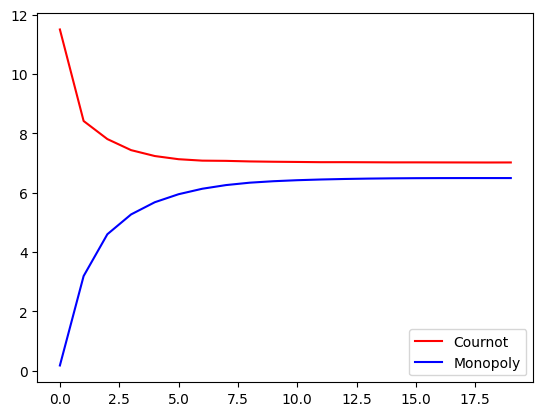

In [3]:
#z1 = np.polyfit(T_list, Obj_c, 4) # 用4次多项式拟合
#z2 = np.polyfit(T_list, Obj_m, 4) # 用4次多项式拟合

#p1 = np.poly1d(z1)
#p2 = np.poly1d(z2)
#yvals1=p1(T_list)
#yvals2=p2(T_list)
plot1=plt.plot(T_list, Obj_c, 'r',label='Cournot')
plot2=plt.plot(T_list, Obj_m, 'b',label='Monopoly')
plt.legend(loc=4)
plt.show()